<a href="https://colab.research.google.com/github/fiifi-oa/NeuralNetworks/blob/main/assignments/A2-shallow-and-deep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A2 · Shallow and Deep Networks

**IMSE 774 · Neural Networks · Formative Assignment 2 · Weeks 3–4**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harunpirim/IMSE774-NeuralNetworks/blob/main/assignments/A2-shallow-and-deep.ipynb)

This assignment spans the two weeks in which the model stops being a straight line:

- **Week 3 — [Shallow Neural Networks](https://harunpirim.github.io/IMSE774-NeuralNetworks/notes/03-shallow-networks.html)**: Prince, *Understanding Deep Learning*, Chapter 3.
- **Week 4 — [Deep Neural Networks](https://harunpirim.github.io/IMSE774-NeuralNetworks/notes/04-deep-networks.html)**: Prince, Chapter 4.

### What "formative" means here

As in A1, the purpose is feedback, not ranking. Chapters 3 and 4 are about what a network *can represent*; Chapters 5–7 are about how to *find* the parameters, and they assume the picture built here — joints, activation patterns, linear regions, folding, and the matrix form $\mathbf{h}_{k+1} = a[\boldsymbol{\beta}_k + \boldsymbol{\Omega}_k \mathbf{h}_k]$ — is solid. Almost every task ends in a **self-check**; the written prompts ask for the reasoning. An honest wrong answer with your reasoning is more useful to both of us than a right answer you cannot explain.

### How to work

1. **File → Save a copy in Drive**, so your edits persist.
2. Run the **Setup** cell first. Every later cell depends on the names it defines.
3. Work top to bottom. Blanks look like `None`, `...`, or `# YOUR CODE HERE`. Written prompts have a cell that starts with *Your answer:* — write directly in it (double-click to edit).
4. Run the check cell under each task. ✅ means the idea landed; ❌ comes with a hint that says where to look; ⬜ means you have not answered yet.
5. When you are done, **Runtime → Run all**, confirm there are no errors, and run the **Summary** at the bottom.
6. **Submit on Blackboard under Assignment A2.** Download your notebook with **File → Download → Download .ipynb** and upload that file, named `A2_<lastname>.ipynb`. Do not submit a link to your Drive copy. The deadline is posted on Blackboard.

Budget about **4 hours**. Times next to each task are rough. You may use any resource, including the course notebooks and the textbook, but write your own code and your own sentences.

| Part | Covers | Tasks |
|:--|:--|:--|
| **A** | Shallow networks: joints, activation patterns, slopes, linear collapse, symmetries, counting regions and parameters, a trained network taken apart | A1–A6 |
| **B** | Deep networks: composition and folding, the rank-one connection, hyperparameters and shapes, regions versus parameters, clipping, the identity trick, what is proved and what is not | B1–B7 |
| **C** | In PyTorch: realized versus maximum regions, and a small experiment | C1–C2 |
| **D** | Self-assessment | D1 |

## Setup

Run this first. It imports the libraries, fixes the random seeds, defines the self-check helpers, and loads the one network that both chapters keep returning to: Prince's ten-parameter example from figure 3.3, with the parameters he lists in problem 3.8.

In [1]:
import hashlib
from math import comb
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(774)
np.random.seed(774)
rng = np.random.default_rng(774)

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

NDSU_GREEN = "#005643"
NDSU_GOLD  = "#FFC72C"
ACCENT     = "#C1121F"

# ---------------------------------------------------------------------------
# Prince's ten-parameter network (figure 3.3; parameters from problem 3.8).
# theta[d] = (theta_d0, theta_d1) feeds hidden unit d; phi weights the outputs.
# ---------------------------------------------------------------------------
THETA = np.array([[-0.2,  0.4],
                  [-0.9,  0.9],
                  [ 1.1, -0.7]])
PHI0  = -0.23
PHI   = np.array([-1.3, 1.3, 0.66])

# ---------------------------------------------------------------------------
# Self-check helpers. A failed check is feedback, never a crash.
# ---------------------------------------------------------------------------
_RESULTS = {}

def _key(s):
    return " ".join(str(s).strip().lower().replace("_", " ").split())

def _fingerprint(s):
    return hashlib.sha256(_key(s).encode()).hexdigest()[:12]

def check(label, ok, hint=""):
    """Record and print one pass/fail line. Pass ok=None for 'not answered yet'."""
    if ok is None:
        _RESULTS[label] = False
        print("⬜ " + label + "   ← not answered yet")
        return False
    ok = bool(ok)
    _RESULTS[label] = ok
    print(("✅ " if ok else "❌ ") + label + ("" if ok or not hint else "   ← " + hint))
    return ok

def _join(*parts):
    """'a|b|c' for the fingerprint checks, or None if any part is still blank."""
    return None if any(p is None for p in parts) else "|".join(str(p) for p in parts)

def check_answer(label, given, fingerprint, hint=""):
    """Compare a short written answer with a fingerprint of the expected one.
    Case, spacing, and underscores are ignored."""
    if given is None or (isinstance(given, str) and not given.strip()):
        _RESULTS[label] = False
        print("⬜ " + label + "   ← not answered yet")
        return False
    return check(label, _fingerprint(given) == fingerprint, hint)

def check_close(label, got, want, tol=1e-3, hint=""):
    """Numerical comparison with a relative and absolute tolerance."""
    if got is None:
        _RESULTS[label] = False
        print("⬜ " + label + "   ← not answered yet")
        return False
    try:
        ok = np.allclose(np.asarray(got, dtype=float), np.asarray(want, dtype=float),
                         rtol=tol, atol=tol)
    except Exception:
        ok = False
    return check(label, ok, hint)

def summary():
    parts = {}
    for label, ok in _RESULTS.items():
        part = label[0]
        parts.setdefault(part, [0, 0])
        parts[part][0] += int(ok)
        parts[part][1] += 1
    print(f"{'part':<6}{'passed':>8}{'of':>6}")
    print("-" * 20)
    for part in sorted(parts):
        p, n = parts[part]
        print(f"{part:<6}{p:>8}{n:>6}")
    p = sum(v[0] for v in parts.values()); n = sum(v[1] for v in parts.values())
    print("-" * 20)
    print(f"{'all':<6}{p:>8}{n:>6}")
    missing = [k for k, v in _RESULTS.items() if not v]
    if missing:
        print("\nNot yet passing:", ", ".join(missing))

print("Setup complete. torch", torch.__version__, "· numpy", np.__version__)

Setup complete. torch 2.11.0+cpu · numpy 2.1.3


## Part A — Shallow networks

*Week 3 note; Prince, Chapter 3.*

A shallow network is linear, then nonlinear, then linear again. With ReLU activations the result is a continuous piecewise linear function, and everything about it — where it bends, how steep each piece is, how many pieces there can be — can be read off the parameters. Part A makes sure you can do that reading.

### A1 · Take the ten-parameter network apart *(20 min)*

*(UDL problems 3.2, 3.3, 3.8, 3.9.)* The network is

$$
y = \phi_0 + \phi_1\, a[\theta_{10} + \theta_{11}x] + \phi_2\, a[\theta_{20} + \theta_{21}x] + \phi_3\, a[\theta_{30} + \theta_{31}x],
$$

with $a[\cdot]$ the ReLU and the parameters `THETA`, `PHI0`, `PHI` from the setup cell.

1. Implement `shallow_1d`, which evaluates the network at every entry of a NumPy array `x` and also returns the $3 \times n$ matrix of **pre-activations** (the values fed into the ReLUs). Everything else in Parts A and B is built on this function.
2. **By hand**, compute the three joints, $x = -\theta_{d0}/\theta_{d1}$, and enter them in increasing order.
3. For each of the four regions, list which hidden units are **active** and compute the region's **slope** by hand, using only the active units: slope $= \sum_{d \text{ active}} \theta_{d1}\phi_d$.

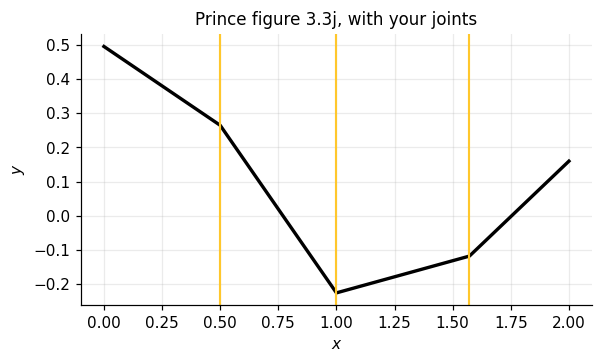

In [2]:
def shallow_1d(x, theta, phi0, phi):
    """Shallow ReLU network with one input and one output, evaluated at every x.
    Returns (y, pre) where pre has shape (D, len(x)) and holds theta_d0 + theta_d1 x."""
    x = np.asarray(x, dtype=float)

    pre = theta[:, 0:1] + theta[:, 1:2] * x[None, :]                                   # YOUR CODE HERE: shape (D, len(x))
    y = phi0 + phi @ np.maximum(pre, 0)                                     # YOUR CODE HERE: phi0 + sum_d phi_d ReLU(pre_d)
    return y, pre

# By hand, from THETA. Increasing order.
joints_by_hand = [0.5, 1.0, 1.57142857]

# Which hidden units are active in each region, left to right? Use "h1", "h2", "h3".
active_by_hand = {
     1: ["h3"],
    2: ["h1", "h3"],
    3: ["h1", "h2", "h3"],
    4: ["h1", "h2"]
}

# The slope of each region, by hand, from the active units only.
slopes_by_hand = {1: -0.462,
    2: -0.982,
    3: 0.188,
    4: 0.650
}

x_grid = np.linspace(0, 2, 2001)
y_grid, pre_grid = shallow_1d(x_grid, THETA, PHI0, PHI)
if y_grid is not None:
    plt.figure(figsize=(6, 3.2))
    plt.plot(x_grid, y_grid, color="k", lw=2.2)
    for j in joints_by_hand:
        if j is not None:
            plt.axvline(j, color=NDSU_GOLD, lw=1.4)
    plt.xlabel("$x$"); plt.ylabel("$y$"); plt.title("Prince figure 3.3j, with your joints"); plt.show()

In [3]:
def _ref_shallow(x, theta, phi0, phi):
    pre = theta[:, 0:1] + theta[:, 1:2] * np.asarray(x, float)[None, :]
    return phi0 + phi @ np.maximum(pre, 0), pre

_y_ref, _pre_ref = _ref_shallow(x_grid, THETA, PHI0, PHI)
check_close("A1 shallow_1d output", y_grid, _y_ref, tol=1e-9,
            hint="y = phi0 + phi @ np.maximum(pre, 0); pre is theta[:, 0:1] + theta[:, 1:2] * x[None, :].")
check("A1 shallow_1d pre-activations have shape (3, n)",
      None if pre_grid is None else np.shape(pre_grid) == (3, len(x_grid)) and np.allclose(pre_grid, _pre_ref),
      "One row per hidden unit, one column per input.")

_joints = np.sort(-THETA[:, 0] / THETA[:, 1])
check_close("A1 joints by hand", None if None in joints_by_hand else joints_by_hand, _joints, tol=1e-3,
            hint="Each joint is where a pre-activation crosses zero: x = -theta_d0 / theta_d1.")

_probes = [0.25, 0.75, 1.3, 1.8]
_active_ref = [[f"h{d + 1}" for d in np.where(THETA[:, 0] + THETA[:, 1] * p > 0)[0]] for p in _probes]
for r, want in zip(range(1, 5), _active_ref):
    got = active_by_hand[r]
    check(f"A1 active units in region {r}", None if got is None else sorted(got) == sorted(want),
          "A unit is active where its pre-activation theta_d0 + theta_d1 x is positive.")

_h = 1e-6
for r, p in zip(range(1, 5), _probes):
    _meas = (_ref_shallow([p + _h], THETA, PHI0, PHI)[0][0] - _ref_shallow([p - _h], THETA, PHI0, PHI)[0][0]) / (2 * _h)
    check_close(f"A1 slope of region {r}", slopes_by_hand[r], _meas, tol=1e-4,
                hint="Sum theta_d1 * phi_d over the active units only; phi_0 never affects slope.")

✅ A1 shallow_1d output
✅ A1 shallow_1d pre-activations have shape (3, n)
✅ A1 joints by hand
✅ A1 active units in region 1
✅ A1 active units in region 2
✅ A1 active units in region 3
✅ A1 active units in region 4
✅ A1 slope of region 1
✅ A1 slope of region 2
✅ A1 slope of region 3
✅ A1 slope of region 4


**Written.** Problem 3.9 says the slope of region 3 equals the slope of region 1 plus the slope of region 4. Using your activation patterns, explain in two sentences why this is forced by the structure of the network rather than a coincidence of these parameters. Then state how many of the four slopes are free to be chosen independently.

*Your answer:* In region 3, all three hidden units are active. Region 1 contains only h3, while region 4 contains h1 and h2. Therefore, the active units in regions 1 and 4 together include all three units, so their slope contributions add to the slope in region 3.

Three slopes are independently free. The fourth slope is constrained by the relationship between the other three.

### A2 · The activation must be nonlinear *(15 min)*

*(UDL problem 3.1; Week 3 §3.4.)* Replace the ReLU with the identity, $a[z] = z$, in a general shallow network with $D_i = 4$ inputs, $D = 32$ hidden units, and $D_o = 2$ outputs,
$$
\mathbf{h} = \boldsymbol{\theta}_0 + \boldsymbol{\Theta}\mathbf{x}, \qquad \mathbf{y} = \boldsymbol{\phi}_0 + \boldsymbol{\Phi}\mathbf{h}.
$$
Show that the whole network is one affine map $\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{b}$ by computing $\mathbf{A}$ and $\mathbf{b}$ from the parameters, then answer the two short questions.

In [4]:
Di, D, Do = 4, 32, 2
Theta, theta0 = rng.standard_normal((D, Di)), rng.standard_normal(D)
Phi_m, phi0_v = rng.standard_normal((Do, D)), rng.standard_normal(Do)

x_batch = rng.standard_normal((6, Di))                     # six inputs, one per row
h_lin = theta0 + x_batch @ Theta.T                         # identity activation
y_lin = phi0_v + h_lin @ Phi_m.T                           # network output, one row per input

A = Phi_m @ Theta                                                   # YOUR CODE HERE: shape (Do, Di)
b = Phi_m @ theta0 + phi0_v                                                   # YOUR CODE HERE: shape (Do,)
y_affine = b + x_batch @ A.T

# If the activation were the *linear* function a[z] = psi_0 + psi_1 z instead of the identity,
# what family would the network describe? One of: "linear", "piecewise linear", "nonlinear"
family_with_linear_activation = "linear"

# And how many linear regions would such a network have, whatever D is?
regions_with_linear_activation = 1

In [5]:
check("A2 A has shape (Do, Di)", None if A is None else np.shape(A) == (Do, Di), "A maps 4 inputs to 2 outputs.")
check_close("A2 affine map reproduces the network", y_affine, y_lin, tol=1e-9,
            hint="Substitute h into y: A = Phi @ Theta and b = Phi @ theta0 + phi0.")
check_answer("A2 family with a linear activation", family_with_linear_activation, "7f2fe580edb3",
             "A linear function of a linear function of a linear function is still linear.")
check_close("A2 regions with a linear activation", regions_with_linear_activation, 1, tol=0,
            hint="No clipping, no joints, no bends.")

✅ A2 A has shape (Do, Di)
✅ A2 affine map reproduces the network
✅ A2 family with a linear activation
✅ A2 regions with a linear activation


True

**Written.** In one sentence each: what did the 32 hidden units buy in this network, and what single property of the ReLU restores their value?

*Your answer:* With a linear activation, the 32 hidden units do not add nonlinear representational power because the whole network is still just one affine map.

The ReLU's nonlinearity creates piecewise-linear regions and allows the network to bend, giving the hidden units nonlinear representational capacity.

### A3 · The parameters are not unique *(15 min)*

*(UDL problems 3.5, 3.6, 3.7.)* The ReLU is **non-negatively homogeneous**: $\mathrm{ReLU}[\alpha z] = \alpha\,\mathrm{ReLU}[z]$ for $\alpha > 0$. Use this to build two *different* parameter vectors that compute *exactly the same function* as the ten-parameter network, and one that does not.

1. Multiply $\theta_{10}$ and $\theta_{11}$ by $\alpha = 2.5$ and divide $\phi_1$ by $2.5$.
2. Do the same with $\alpha = -2$.
3. Swap the roles of hidden units 1 and 2 (their $\theta$ rows *and* their $\phi$ weights).

In [6]:
def rescaled(theta, phi0, phi, alpha, d=0):
    """Multiply hidden unit d's incoming parameters by alpha and divide its outgoing weight by alpha."""
    theta2, phi2 = theta.copy(), phi.copy()

    theta2[d] *= alpha
    phi2[d] /= alpha
    return theta2, phi0, phi2

def swapped(theta, phi0, phi, d1=0, d2=1):
    """Exchange hidden units d1 and d2."""
    theta2, phi2 = theta.copy(), phi.copy()

    theta2[d1], theta2[d2] = theta[d2].copy(), theta[d1].copy()
    phi2[d1], phi2[d2] = phi[d2], phi[d1]

    return theta2, phi0, phi2

y_base, _ = shallow_1d(x_grid, THETA, PHI0, PHI)
y_pos,  _ = shallow_1d(x_grid, *rescaled(THETA, PHI0, PHI, 2.5))
y_neg,  _ = shallow_1d(x_grid, *rescaled(THETA, PHI0, PHI, -2.0))
y_swap, _ = shallow_1d(x_grid, *swapped(THETA, PHI0, PHI))

# For each transformation: is the function "unchanged" or "changed"?
effect_alpha_positive = "unchanged"
effect_alpha_negative = "changed"
effect_swap           = "unchanged"

# Fit this network by least squares. Does the loss have a unique minimizing parameter vector? True / False
loss_has_unique_minimum = False

In [7]:
_t, _, _p = rescaled(THETA, PHI0, PHI, 2.5)
check("A3 rescaled changes exactly one unit's parameters",
      None if np.allclose(_t, THETA) and np.allclose(_p, PHI) else np.allclose(_t[0], 2.5 * THETA[0]) and np.isclose(_p[0], PHI[0] / 2.5) and np.allclose(_t[1:], THETA[1:]) and np.allclose(_p[1:], PHI[1:]),
      "Scale row d of theta by alpha and entry d of phi by 1/alpha; leave the others alone.")
_t, _, _p = swapped(THETA, PHI0, PHI)
check("A3 swapped exchanges two units",
      None if np.allclose(_t, THETA) and np.allclose(_p, PHI) else np.allclose(_t[0], THETA[1]) and np.allclose(_t[1], THETA[0]) and np.isclose(_p[0], PHI[1]) and np.isclose(_p[1], PHI[0]),
      "Swap rows d1 and d2 of theta and entries d1 and d2 of phi.")
check("A3 alpha > 0 leaves the function unchanged", None if y_pos is None else np.allclose(y_pos, y_base),
      "ReLU[alpha z] = alpha ReLU[z] for alpha > 0, and the 1/alpha in phi cancels it.")
check("A3 alpha < 0 changes the function", None if y_neg is None else not np.allclose(y_neg, y_base),
      "ReLU[-2z] is not -2 ReLU[z]: the unit is now active on the other side of its joint.")
check_answer("A3 effects", _join(effect_alpha_positive, effect_alpha_negative, effect_swap),
             "6abb9a332ff8",
             "Read the three np.allclose comparisons above.")
check("A3 uniqueness of the minimum", None if loss_has_unique_minimum is None else loss_has_unique_minimum is False,
      "If phi* minimizes the loss, so does every rescaling and every permutation of it.")

✅ A3 rescaled changes exactly one unit's parameters
✅ A3 swapped exchanges two units
✅ A3 alpha > 0 leaves the function unchanged
✅ A3 alpha < 0 changes the function
✅ A3 effects
✅ A3 uniqueness of the minimum


True

**Written.** Explain why the negative $\alpha$ changes the function even though $\mathrm{ReLU}[\alpha z] = \alpha\,\mathrm{ReLU}[z]$ looks like it should still hold. Then say what your answers imply about the loss surface that Chapter 6 will have to search: how many global minima does the ten-parameter network have, at least?

*Your answer:* The negative α changes the function because the ReLU homogeneity property only holds for α > 0. When α is negative, the sign of the pre-activation is reversed, so the unit becomes active on the opposite side of its joint. Therefore, ReLU[-2z] is not equal to -2 ReLU[z].

These results mean that the loss surface has multiple global minima. In fact, the ten-parameter network has infinitely many global minima because positive rescaling can produce continuously many different parameter vectors with exactly the same function, in addition to permutations of hidden units.

### A4 · Count parameters and regions *(20 min)*

*(UDL problems 3.11, 3.15, 3.17, 3.18; Week 3 exercise 8.)* For a shallow network with $D_i$ inputs, $D$ hidden units, and $D_o$ outputs, the parameter count is
$$
D(D_i + 1) + D_o(D + 1),
$$
and the maximum number of linear regions is the number of cells that $D$ hyperplanes can cut a $D_i$-dimensional space into (Zaslavsky, 1975):
$$
N_r = \sum_{j=0}^{D_i} \binom{D}{j}.
$$
Implement both, then fill in the table by hand *before* running the check, which builds each network in PyTorch and counts.

In [ ]:
def n_params_shallow(Di, D, Do):
    return None                                            # YOUR CODE HERE

def max_regions_shallow(D, Di):
    """Zaslavsky's bound. Use Python ints (math.comb); these numbers overflow int64."""
    return None                                            # YOUR CODE HERE

# By hand:
params_fig_3_11        = None     # figure 3.11: Di = 3, D = 3, Do = 2
regions_fig_3_11       = None     # its maximum number of linear regions
regions_2in_3units     = None     # figure 3.8: Di = 2, D = 3
regions_2in_5units     = None     # ... with two more hidden units
params_bearing_model   = None     # Week 3 exercise 8: Di = 64, D = 256, Do = 1

cases = {"fig 3.11 (3, 3, 2)": (3, 3, 2), "fig 3.8 (2, 3, 1)": (2, 3, 1),
         "two inputs, five units (2, 5, 1)": (2, 5, 1), "bearing model (64, 256, 1)": (64, 256, 1)}
print(f"{'network':<36}{'parameters':>12}{'max regions':>26}")
for name, (Di_, D_, Do_) in cases.items():
    p, r = n_params_shallow(Di_, D_, Do_), max_regions_shallow(D_, Di_)
    print(f"{name:<36}{'—' if p is None else f'{p:>12,}'}{'—' if r is None else f'{r:>26.3g}'}")

In [ ]:
def _torch_count(Di_, D_, Do_):
    m = nn.Sequential(nn.Linear(Di_, D_), nn.ReLU(), nn.Linear(D_, Do_))
    return sum(p.numel() for p in m.parameters())

_all_ok = True
for name, (Di_, D_, Do_) in cases.items():
    got = n_params_shallow(Di_, D_, Do_)
    _all_ok = _all_ok and got is not None and got == _torch_count(Di_, D_, Do_)
check("A4 n_params_shallow agrees with PyTorch on every case",
      None if n_params_shallow(3, 3, 2) is None else _all_ok,
      "Each hidden unit has Di weights and one bias; each output has D weights and one bias.")

_z = lambda D_, Di_: sum(comb(D_, j) for j in range(0, min(D_, Di_) + 1))
check("A4 max_regions_shallow matches Zaslavsky's sum",
      None if max_regions_shallow(3, 2) is None else all(max_regions_shallow(D_, Di_) == _z(D_, Di_) for D_ in (1, 3, 5, 20) for Di_ in (1, 2, 3, 10)),
      "Sum comb(D, j) for j = 0 ... Di.")
check_close("A4 parameters of figure 3.11", params_fig_3_11, 20, tol=0, hint="3 * (3 + 1) + 2 * (3 + 1).")
check_close("A4 regions of figure 3.11", regions_fig_3_11, 8, tol=0, hint="Three planes in 3D: 1 + 3 + 3 + 1.")
check_close("A4 regions, two inputs, three units", regions_2in_3units, 7, tol=0, hint="1 + 3 + 3.")
check_close("A4 regions, two inputs, five units", regions_2in_5units, 16, tol=0, hint="1 + 5 + C(5, 2).")
check_close("A4 parameters of the bearing model", params_bearing_model, 256 * 65 + 257, tol=0, hint="256 * (64 + 1) + 1 * (256 + 1).")

**Written.** The bearing model has about seventeen thousand parameters and a region count with dozens of digits. In two sentences, explain why Prince concludes that expressivity is not the bottleneck in deep learning, and name the two things that are the bottleneck for a dataset of two hundred failed bearings.

*Your answer:*

### A5 · Two inputs: regions are cells, not truth-table rows *(15 min)*

*(Week 3 §3.3.2.)* With two inputs each hidden unit is a plane over the input, clipped along the line where it crosses zero, and the regions are the cells those lines cut the plane into. Three lines in general position make seven cells, but three units have $2^3 = 8$ conceivable on/off patterns. Count the realized patterns for the network below, find the missing one, and then check that adding units never beats Zaslavsky's bound.

In [ ]:
th2 = np.array([[-0.3,  1.0,  0.6],
                [ 0.2, -0.8,  1.1],
                [-0.5, -0.7, -1.0]])                       # rows: theta_d0, theta_d1, theta_d2

g = np.linspace(-2, 2, 401)
X1, X2 = np.meshgrid(g, g)
grid = np.stack([X1.ravel(), X2.ravel()], axis=1)          # (n_points, 2)

def activation_patterns(theta, points):
    """Boolean array (n_points, D): True where hidden unit d is active at each point."""
    return None                                            # YOUR CODE HERE

def realized_regions(theta, points):
    """Number of distinct activation patterns over the sampled points."""
    return None                                            # YOUR CODE HERE

n_realized = realized_regions(th2, grid)
missing_pattern_active = None      # the units that are active in the pattern that never occurs, e.g. ["h1", "h3"]

# Add two random hidden units. Is the realized count still <= Zaslavsky's bound? Record the two numbers.
th5 = np.vstack([th2, rng.standard_normal((2, 3))])
n_realized_5 = None                # YOUR CODE HERE
bound_5      = None                # YOUR CODE HERE, from A4
print("realized regions, 3 units:", n_realized, "   5 units:", n_realized_5, "   bound for 5 units:", bound_5)

In [ ]:
_pat = (th2[:, 0] + grid @ th2[:, 1:].T) > 0
_seen = {tuple(r) for r in np.unique(_pat, axis=0)}
_missing = [p for p in [(a, b, c) for a in (False, True) for b in (False, True) for c in (False, True)] if p not in _seen]
check("A5 activation_patterns has shape (n_points, 3)",
      None if activation_patterns(th2, grid) is None else np.shape(activation_patterns(th2, grid)) == (grid.shape[0], 3),
      "pre = theta[:, 0] + points @ theta[:, 1:].T, then pre > 0.")
check_close("A5 realized regions with three units", n_realized, len(_seen), tol=0,
            hint="np.unique(patterns, axis=0) counts distinct rows.")
_want_missing = sorted(f"h{i + 1}" for i, on in enumerate(_missing[0]) if on) if len(_missing) == 1 else None
check("A5 the missing pattern", None if missing_pattern_active is None else sorted(missing_pattern_active) == _want_missing,
      "Which of the eight on/off combinations does np.unique never return?")
check("A5 five units stay within the bound",
      None if n_realized_5 is None or bound_5 is None else 7 < n_realized_5 <= bound_5 == 16,
      "Two more lines add regions, but never more than 1 + 5 + C(5, 2).")

**Written.** Why is there no region where all three units are active, in terms of the three half-planes? And why does a shallow network with $D$ hidden units in $D_i = 2$ dimensions realize far fewer than $2^D$ regions once $D$ is large?

*Your answer:*

### A6 · Take a trained network apart *(25 min)*

*(Week 3 §"Building One in PyTorch"; exercise 9.)* Everything in A1 applies to a network that gradient descent found, not just one Prince wrote down. The cell below fits a twelve-unit shallow network to noisy data; it is written for you. Your job is to read the trained parameters back out:

1. `learned_joints`: where each hidden unit's pre-activation crosses zero, $x = -\theta_{d0}/\theta_{d1}$, from `model[0].weight` and `model[0].bias`.
2. `region_slope(x0)`: the slope of the trained function at a point $x_0$ from the parameters alone, $\sum_{d \text{ active at } x_0} \theta_{d1}\phi_d$, using the second layer's weights for $\phi_d$.

The check compares your slopes with finite differences of the trained model.

In [ ]:
def f_true(x):
    return np.sin(3 * x) + 0.35 * x ** 2

torch.manual_seed(774); np.random.seed(774)
x_train = np.random.uniform(-2, 2, 200)
y_train = f_true(x_train) + np.random.normal(0, 0.12, x_train.shape)
Xt = torch.tensor(x_train, dtype=torch.float32).unsqueeze(1)
Yt = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

D = 12
model = nn.Sequential(nn.Linear(1, D), nn.ReLU(), nn.Linear(D, 1))
opt = torch.optim.Adam(model.parameters(), lr=0.05)
for epoch in range(3000):
    opt.zero_grad(); loss = nn.MSELoss()(model(Xt), Yt); loss.backward(); opt.step()
print(f"trained: D = {D}, final MSE = {loss.item():.4f}")

with torch.no_grad():
    W1 = model[0].weight.squeeze().numpy().astype(float)     # theta_d1, shape (D,)
    b1 = model[0].bias.numpy().astype(float)                  # theta_d0, shape (D,)
    W2 = model[2].weight.squeeze().numpy().astype(float)      # phi_d,    shape (D,)
    b2 = float(model[2].bias.item())                          # phi_0

learned_joints = None                                         # YOUR CODE HERE: shape (D,)

def region_slope(x0):
    """Slope of the trained network at x0, from the parameters only."""
    return None                                               # YOUR CODE HERE

with torch.no_grad():
    xg = np.linspace(-2.2, 2.2, 800)
    yg = model(torch.tensor(xg, dtype=torch.float32).unsqueeze(1)).squeeze().numpy()
plt.figure(figsize=(6.5, 3.4))
plt.scatter(x_train, y_train, s=10, color="gray", alpha=0.5, label="data")
plt.plot(xg, yg, color=NDSU_GREEN, lw=2.2, label="network")
if learned_joints is not None:
    jj = learned_joints[(learned_joints > -2.2) & (learned_joints < 2.2)]
    plt.plot(jj, np.interp(jj, xg, yg), "o", color=NDSU_GOLD, mec="k", mew=0.6, ms=6, label="joints", zorder=5)
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(fontsize=8); plt.show()

In [ ]:
check_close("A6 learned joints", None if learned_joints is None else np.sort(learned_joints), np.sort(-b1 / W1), tol=1e-6,
            hint="x = -theta_d0 / theta_d1, elementwise over the D units.")

# Probe halfway between consecutive in-range joints, so no probe sits on a joint.
_j = np.sort(np.concatenate([[-2.0], np.sort(-b1 / W1)[(np.sort(-b1 / W1) > -2) & (np.sort(-b1 / W1) < 2)], [2.0]]))
_probes = 0.5 * (_j[:-1] + _j[1:])
import copy
_m64 = copy.deepcopy(model).double()                 # float64 copy: the function is linear between joints, so the
_hfd = min(1e-3, 0.25 * np.min(np.diff(_j)))         # difference quotient is exact as long as no joint sits within h
def _fd(x0):
    with torch.no_grad():
        f = lambda v: _m64(torch.tensor([[v]], dtype=torch.float64)).item()
    return (f(x0 + _hfd) - f(x0 - _hfd)) / (2 * _hfd)
_got = [region_slope(p) for p in _probes]
check_close("A6 region slopes from parameters match finite differences",
            None if any(v is None for v in _got) else _got, [_fd(p) for p in _probes], tol=1e-3,
            hint="Sum W1[d] * W2[d] over the units whose pre-activation b1[d] + W1[d] * x0 is positive.")
check("A6 joints concentrate where the curve bends",
      None if learned_joints is None else int(np.sum(np.abs(learned_joints) < 2.2)) >= 6,
      "Most of the 12 joints should land inside the data range; if not, something is off in the sign or division.")

**Written.** Replace `nn.ReLU()` with `nn.Sigmoid()` in your head (or in a scratch cell). Is the fitted function still piecewise linear? What does $-\theta_{d0}/\theta_{d1}$ mean for a sigmoid unit, and why does the chapter (and this course) nevertheless stick with the ReLU? Three or four sentences; Prince pp. 37–38.

*Your answer:*

## Part B — Deep networks

*Week 4 note; Prince, Chapter 4.*

More than one hidden layer changes nothing about the *kind* of function (still continuous and piecewise linear) and everything about the exchange rate between parameters and linear regions. Part B builds that claim from the composition of two shallow networks to the general matrix form, and then asks which parts of the case for depth are proved.

### B1 · Composition multiplies regions *(25 min)*

*(UDL problem 4.1; Week 4 §4.1.)* Feed the output of one shallow network into another. If the first network's regions each sweep the *whole* output range, the second network's function is replicated once per region. The first network below is a zigzag on $[-1, 1]$ with slopes $3, -3, 3$; the second is any three-region function.

1. Implement `compose`, which passes `x` through a list of networks in order and returns the final output together with the list of pre-activation matrices, one per network.
2. Implement `count_regions`, which counts distinct activation patterns across **all** hidden units of all layers, since each linear region of the composition has its own pattern.
3. Predict, then verify, the region counts for the zigzag composed with itself $K = 1, 2, 3, 4$ times.

In [ ]:
# Network A: zigzag on [-1, 1], joints at -1/3 and 1/3, each region sweeps y in [-1, 1].
theta_A, phi0_A, phi_A = np.array([[1.0, 1.0], [1/3, 1.0], [-1/3, 1.0]]), -1.0, np.array([3.0, -6.0, 6.0])
# Network B: a three-region function of its input on [-1, 1].
theta_B, phi0_B, phi_B = np.array([[1.0, 1.0], [0.5, 1.0], [-0.3, 1.0]]), 0.6, np.array([-2.0, 3.5, -2.5])

xs = np.linspace(-1, 1, 20001)[1:-1]

def compose(x, nets):
    """nets is a list of (theta, phi0, phi). Returns (y, [pre_1, pre_2, ...])."""
    y, pres = np.asarray(x, float), []
    # YOUR CODE HERE: loop over nets, calling shallow_1d on the running output and collecting each pre
    return y, pres

def count_regions(pres):
    """Number of distinct activation patterns across every hidden unit of every layer."""
    return None                                            # YOUR CODE HERE

y_AB, pres_AB = compose(xs, [(theta_A, phi0_A, phi_A), (theta_B, phi0_B, phi_B)])

regions_A_alone  = None       # by hand
regions_B_alone  = None       # by hand
regions_AB       = None       # by hand: what does the folding argument predict?
regions_shallow6 = None       # by hand: most a *shallow* network with the same six hidden units could make

predicted_self_composition = {1: None, 2: None, 3: None, 4: None}   # zigzag composed with itself K times
counted_self_composition   = {K: count_regions(compose(xs, [(theta_A, phi0_A, phi_A)] * K)[1]) for K in (1, 2, 3, 4)}
print("predicted:", predicted_self_composition)
print("counted:  ", counted_self_composition)

if pres_AB:
    fig, axes = plt.subplots(1, 3, figsize=(11, 3))
    axes[0].plot(xs, shallow_1d(xs, theta_A, phi0_A, phi_A)[0], color=NDSU_GREEN, lw=2); axes[0].set_title("network A: $y[x]$")
    axes[1].plot(xs, shallow_1d(xs, theta_B, phi0_B, phi_B)[0], color=ACCENT, lw=2); axes[1].set_title("network B: $y'[y]$")
    axes[2].plot(xs, y_AB, color="k", lw=2); axes[2].set_title(f"composition: {count_regions(pres_AB)} regions")
    for ax in axes: ax.set_xlim(-1, 1)
    plt.tight_layout(); plt.show()

In [ ]:
def _ref_compose(x, nets):
    y, pres = np.asarray(x, float), []
    for th, p0, p in nets:
        y, pre = _ref_shallow(y, th, p0, p); pres.append(pre)
    return y, pres
def _ref_count(pres):
    return len(np.unique(np.concatenate([p > 0 for p in pres], axis=0).T, axis=0))

_y_ref, _pres_ref = _ref_compose(xs, [(theta_A, phi0_A, phi_A), (theta_B, phi0_B, phi_B)])
check_close("B1 compose output", y_AB if pres_AB else None, _y_ref, tol=1e-9,
            hint="Feed the running output y into the next network: y, pre = shallow_1d(y, theta, phi0, phi).")
check("B1 compose returns one pre-activation matrix per network",
      None if not pres_AB else len(pres_AB) == 2 and all(np.allclose(a, b) for a, b in zip(pres_AB, _pres_ref)),
      "Append each network's pre to the list.")
check_close("B1 count_regions on the composition", None if not pres_AB else count_regions(pres_AB), _ref_count(_pres_ref), tol=0,
            hint="Stack (pre > 0) for every layer along axis 0, transpose, and count unique rows.")
check_close("B1 regions by hand: A, B, composition, shallow with 6 units",
            None if None in (regions_A_alone, regions_B_alone, regions_AB, regions_shallow6) else [regions_A_alone, regions_B_alone, regions_AB, regions_shallow6],
            [3, 3, 9, 7], tol=0, hint="Three regions copied once per region of A; a shallow network makes at most D + 1.")
check_close("B1 predicted 3^K for self-composition",
            None if None in predicted_self_composition.values() else [predicted_self_composition[K] for K in (1, 2, 3, 4)],
            [3, 9, 27, 81], tol=0, hint="Each fold triples the count.")
check_close("B1 counted regions match 3^K",
            None if None in counted_self_composition.values() else [counted_self_composition[K] for K in (1, 2, 3, 4)],
            [3, 9, 27, 81], tol=0, hint="If count_regions is right, the counts should be exactly 3, 9, 27, 81.")

**Written.** Twelve hidden units as four layers of three make 81 regions; twelve in one layer make at most 13. State the price of those 81 regions in one sentence, using the word *fold*, and say what property of network A made the multiplication exact rather than "up to".

*Your answer:*

### B2 · Composition is a rank-one two-layer network *(15 min)*

*(Week 4 §4.2.)* Substituting network A's output into network B's hidden units eliminates the intermediate variable and leaves a network with **two hidden layers**, whose second-layer weight matrix is forced to be the outer product
$$
\boldsymbol{\Psi} = \begin{bmatrix} \theta'_{11} \\ \theta'_{21} \\ \theta'_{31} \end{bmatrix}\begin{bmatrix} \phi_1 & \phi_2 & \phi_3 \end{bmatrix},
\qquad
\psi_{d0} = \theta'_{d0} + \theta'_{d1}\phi_0 .
$$
Build $\boldsymbol{\Psi}$ and $\boldsymbol{\psi}_0$ from the parameters of A and B, evaluate the two-layer network directly, and confirm it reproduces the composition.

In [ ]:
Psi  = None                                               # YOUR CODE HERE: (3, 3) outer product
psi0 = None                                               # YOUR CODE HERE: (3,)

def two_layer(x, theta, psi0, Psi, phi0_out, phi_out):
    """h1 = ReLU(theta x); h2 = ReLU(psi0 + Psi h1); y = phi0_out + phi_out . h2"""
    H1 = None                                             # YOUR CODE HERE, shape (3, n)
    H2 = None                                             # YOUR CODE HERE, shape (3, n)
    return None if H2 is None else phi0_out + phi_out @ H2

y_two = None if Psi is None else two_layer(xs, theta_A, psi0, Psi, phi0_B, phi_B)
rank_Psi = None                                           # by hand: the rank of the outer product

In [ ]:
check_close("B2 Psi is the outer product", Psi, np.outer(theta_B[:, 1], phi_A), tol=1e-12,
            hint="psi_ij = theta'_i1 * phi_j: np.outer(theta_B[:, 1], phi_A).")
check_close("B2 psi_0", psi0, theta_B[:, 0] + theta_B[:, 1] * phi0_A, tol=1e-12,
            hint="psi_i0 = theta'_i0 + theta'_i1 * phi_0.")
check_close("B2 two-layer network reproduces the composition", y_two, _y_ref, tol=1e-9,
            hint="ReLU both layers; only the output line has no activation.")
check_close("B2 rank of Psi", rank_Psi, 1, tol=0, hint="An outer product of two vectors has rank one.")

**Written.** A general two-layer network has nine free entries in $\boldsymbol{\Psi}$; the composition has effectively how many? In two sentences, say what the general network can do that the composition cannot, in terms of what the second layer "sees".

*Your answer:*

### B3 · Hyperparameters, shapes, and where the parameters go *(20 min)*

*(UDL problems 4.2, 4.4, 4.5, 4.6.)* In the general notation a network with $K$ hidden layers is
$$
\mathbf{h}_1 = a[\boldsymbol{\beta}_0 + \boldsymbol{\Omega}_0\mathbf{x}], \quad
\mathbf{h}_{k+1} = a[\boldsymbol{\beta}_k + \boldsymbol{\Omega}_k\mathbf{h}_k], \quad
\mathbf{y} = \boldsymbol{\beta}_K + \boldsymbol{\Omega}_K\mathbf{h}_K,
$$
and a PyTorch `nn.Linear` is exactly one $\boldsymbol{\beta}_k + \boldsymbol{\Omega}_k\mathbf{h}_k$. Take $D_i = 5$, $D_o = 4$, and hidden widths $D_1 = 20$, $D_2 = 10$, $D_3 = 7$.

1. Write the shape of every $\boldsymbol{\Omega}_k$ and the length of every $\boldsymbol{\beta}_k$ by hand.
2. Implement `n_params_deep` for arbitrary widths.
3. Decide the depth-versus-width question of problem 4.6 by computing, not guessing.

In [ ]:
def make_mlp(D_i, widths, D_o):
    """A fully connected ReLU network with hidden widths D_1, ..., D_K (given; from the Week 4 note)."""
    layers, d = [], D_i
    for w in widths:
        layers += [nn.Linear(d, w), nn.ReLU()]
        d = w
    layers.append(nn.Linear(d, D_o))
    return nn.Sequential(*layers)

# 1. By hand, for D_i = 5, widths [20, 10, 7], D_o = 4. Shapes as (rows, cols); bias lengths as ints.
Omega_shapes = {0: None, 1: None, 2: None, 3: None}
beta_lengths = {0: None, 1: None, 2: None, 3: None}
K_hidden_layers   = None      # the depth K
n_weight_matrices = None      # how many Omega_k a K-layer network has

# 2. In code, for any widths.
def n_params_deep(D_i, widths, D_o):
    return None                                            # YOUR CODE HERE

# 3. Problem 4.6: D_i = D_o = 1, K = 10 layers of D = 10. Which grows the parameter count more?
params_base       = None                                   # YOUR CODE HERE: n_params_deep(1, [10] * 10, 1)
params_one_deeper = None                                   # YOUR CODE HERE: one more layer of 10
params_one_wider  = None                                   # YOUR CODE HERE: every layer 11 wide
grows_more        = None                                   # "depth" or "width"
print("base:", params_base, " +1 layer:", params_one_deeper, " +1 width:", params_one_wider)

In [ ]:
_net = make_mlp(5, [20, 10, 7], 4)
_lin = [m for m in _net if isinstance(m, nn.Linear)]
check("B3 Omega shapes", None if None in Omega_shapes.values() else all(tuple(Omega_shapes[k]) == tuple(_lin[k].weight.shape) for k in range(4)),
      "Omega_k is (units it produces) x (units it consumes): rows for the next layer, columns for this one.")
check("B3 beta lengths", None if None in beta_lengths.values() else all(beta_lengths[k] == _lin[k].bias.numel() for k in range(4)),
      "One bias per unit of the layer being produced; the last has D_o entries.")
check_close("B3 depth K and number of weight matrices", None if None in (K_hidden_layers, n_weight_matrices) else [K_hidden_layers, n_weight_matrices], [3, 4], tol=0,
            hint="K hidden layers need K + 1 affine maps.")
_ok = n_params_deep(5, [20, 10, 7], 4) is not None and all(
    n_params_deep(di, w, do) == sum(p.numel() for p in make_mlp(di, w, do).parameters())
    for di, w, do in [(5, [20, 10, 7], 4), (1, [10] * 10, 1), (3, [4, 2, 3], 2), (2, [30], 1)])
check("B3 n_params_deep agrees with PyTorch", None if n_params_deep(5, [20, 10, 7], 4) is None else _ok,
      "Sum over consecutive layer sizes (a, b) of b * (a + 1).")
check_close("B3 problem 4.6 counts", None if None in (params_base, params_one_deeper, params_one_wider) else [params_base, params_one_deeper, params_one_wider],
            [1021, 1131, 1222], tol=0, hint="Use n_params_deep with [10]*10, [10]*11, and [11]*10.")
check_answer("B3 which grows more", grows_more, "dec0f004eaa0",
             "A new layer adds D(D + 1) parameters; a new unit in every layer touches every one of the K matrices.")

**Written.** Distinguish *parameters* from *hyperparameters* in one sentence each, and explain what Prince means by calling a neural network "a family of families of functions".

*Your answer:*

### B4 · Regions versus parameters, in one dimension *(15 min)*

*(UDL problems 4.10, 4.11; Week 4 §4.5.2.)* For $D_i = D_o = 1$, a network with $K$ hidden layers of $D > 2$ units each has
$$
3D + 1 + (K - 1)D(D + 1) \;\text{ parameters and up to }\; (D + 1)^K \;\text{ linear regions.}
$$
Implement both formulas and use them to reproduce the numbers the chapter quotes.

In [ ]:
def params_1d(D, K):
    return None                                            # YOUR CODE HERE

def regions_1d(D, K):
    return None                                            # YOUR CODE HERE (Python ints)

# Problem 4.11: shallow with D = 95 versus deep with K = 10, D = 5.
params_shallow95, regions_shallow95 = None, None
params_deep5x10,  regions_deep5x10  = None, None

# The book's headline example: K = 5, D = 10.
params_5x10, regions_5x10 = None, None

# Smallest K for which a network with D = 5 units per layer can exceed one million regions.
smallest_K_over_1e6 = None

In [ ]:
check("B4 params_1d agrees with n_params_deep", None if params_1d(5, 3) is None else all(params_1d(D_, K_) == n_params_deep(1, [D_] * K_, 1) for D_ in (3, 5, 10) for K_ in (1, 2, 5)),
      "3D + 1 + (K - 1) D (D + 1); check it against n_params_deep(1, [D]*K, 1).")
check_close("B4 both problem-4.11 networks have 286 parameters", None if None in (params_shallow95, params_deep5x10) else [params_shallow95, params_deep5x10], [286, 286], tol=0,
            hint="Shallow: 3 * 95 + 1. Deep: 3 * 5 + 1 + 9 * 5 * 6.")
check_close("B4 their maximum regions", None if None in (regions_shallow95, regions_deep5x10) else [regions_shallow95, regions_deep5x10], [96, 6 ** 10], tol=0,
            hint="(D + 1)^K: 96 versus 6^10 = 60,466,176.")
check_close("B4 the headline example", None if None in (params_5x10, regions_5x10) else [params_5x10, regions_5x10], [471, 161051], tol=0,
            hint="K = 5, D = 10: 471 parameters, 11^5 regions.")
check_close("B4 smallest K over a million regions with D = 5", smallest_K_over_1e6, 8, tol=0,
            hint="6^7 = 279,936 and 6^8 = 1,679,616.")

### B5 · Clipping adds joints *(20 min)*

*(Week 4 §4.3.)* The folding picture explains *where* regions multiply; the clipping picture shows the *joints*. Take Prince's figure 3.3 network as the first layer (joints at $0.5$, $1$, $1.57$) and the second-layer parameters below. Each second-layer pre-activation is a piecewise linear function sharing the first layer's joints; every place it crosses zero is a **new** joint. Count them.

In [ ]:
psi0_c = np.array([0.41, -0.45, -0.54])
Psi_c  = np.array([[ 1.1, -1.4, -0.9],
                   [-1.0,  1.3,  1.8],
                   [ 1.8,  0.0,  0.6]])
phi0_c, phi_c = 0.1, np.array([1.0, -0.6, 0.9])

xc = np.linspace(0, 2, 20001)[1:-1]
_, pre1 = shallow_1d(xc, THETA, PHI0, PHI)                 # first-layer pre-activations, (3, n)
H1 = None if pre1 is None else np.maximum(pre1, 0)

pre2 = None                                                 # YOUR CODE HERE: second-layer pre-activations, (3, n)

def zero_crossings(row):
    """How many times a sampled function changes sign."""
    return None                                             # YOUR CODE HERE (np.sign and np.diff)

new_joints_per_unit = None if pre2 is None else [zero_crossings(pre2[d]) for d in range(3)]
joints_layer1       = None                                  # by hand
regions_predicted   = None                                  # 1 + joints from layer 1 + new joints from layer 2
regions_counted     = None if pre2 is None else count_regions([pre1, pre2])
print("new joints per unit:", new_joints_per_unit, "  predicted regions:", regions_predicted, "  counted:", regions_counted)

if pre2 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
    for d, ax in enumerate(axes):
        ax.plot(xc, pre2[d], lw=2, color=[ACCENT, "#1864AB", NDSU_GREEN][d]); ax.axhline(0, color="k", lw=0.6)
        for j in -THETA[:, 0] / THETA[:, 1]:
            ax.axvline(j, color="gray", ls=":", lw=0.9)
        ax.set_title(f"layer-2 pre-activation {d + 1}")
    plt.tight_layout(); plt.show()

In [ ]:
_pre1 = _ref_shallow(xc, THETA, PHI0, PHI)[1]
_pre2 = psi0_c[:, None] + Psi_c @ np.maximum(_pre1, 0)
_zc = [int(np.sum(np.diff(np.sign(_pre2[d])) != 0)) for d in range(3)]
check_close("B5 second-layer pre-activations", pre2, _pre2, tol=1e-9, hint="psi0[:, None] + Psi @ H1.")
check_close("B5 new joints per unit", new_joints_per_unit, _zc, tol=0, hint="Count sign changes: np.sum(np.diff(np.sign(row)) != 0).")
check_close("B5 predicted regions equal counted regions",
            None if None in (regions_predicted, regions_counted) else [regions_predicted, regions_counted],
            [1 + 3 + sum(_zc), _ref_count([_pre1, _pre2])], tol=0,
            hint="Regions = 1 + total joints, and both layers' joints count.")

**Written.** Six hidden units in one layer give at most six joints, one per unit. Why can six units in two layers give more? Answer in terms of what kind of function each layer's pre-activation is. Then explain why the folding and clipping pictures are two views of the same computation, and what each one hides (Prince p. 46).

*Your answer:*

### B6 · The identity trick *(15 min)*

*(UDL problem 4.7; Week 4 §4.5.1.)* Choose the ten parameters of the shallow network so that it computes $y = x$ exactly for every $x \in [0, 2]$. There are many solutions; any that passes is fine. Then explain what this buys.

In [ ]:
theta_id = np.array([[None, None],
                     [None, None],
                     [None, None]], dtype=object)           # YOUR CODE HERE: replace every None with a number
phi0_id  = None
phi_id   = np.array([None, None, None], dtype=object)       # YOUR CODE HERE

_ready = not any(v is None for v in list(theta_id.ravel()) + [phi0_id] + list(phi_id))
if _ready:
    y_id, _ = shallow_1d(x_grid, theta_id.astype(float), float(phi0_id), phi_id.astype(float))
    print("max |y - x| on [0, 2]:", np.abs(y_id - x_grid).max())

In [ ]:
check("B6 network computes the identity on [0, 2]",
      None if not _ready else np.allclose(_ref_shallow(x_grid, theta_id.astype(float), float(phi0_id), phi_id.astype(float))[0], x_grid, atol=1e-9),
      "Make one unit active on the whole interval, e.g. ReLU[1 + x], and undo its offset with phi_0.")

**Written.** Use your construction to argue in two or three sentences that "a deep network can approximate any continuous function" follows from the shallow universal approximation theorem rather than being a new theorem. Then say why this comparison, on its own, says nothing about which architecture is *better*.

*Your answer:*

### B7 · What is proved and what is observed *(10 min)*

*(Week 4 §4.5.)* Prince compares shallow and deep networks along several lines. Sort the five claims below into what kind of statement each one is. Use exactly one of `"theorem"`, `"counting argument"`, `"empirical"`.

In [ ]:
kinds = ["theorem", "counting argument", "empirical"]
claims = {
    "a": None,   # Both shallow and deep networks can approximate any continuous function on a compact set.
    "b": None,   # A deep network makes many more linear regions per parameter than a shallow one.
    "c": None,   # Some functions need exponentially more shallow units than deep ones to reach the same error (depth efficiency).
    "d": None,   # Moderately deep networks are usually easier to fit than shallow ones of similar capacity.
    "e": None,   # Deep networks tend to generalize better to new data.
}

In [ ]:
for k, v in claims.items():
    if v is not None and v not in kinds:
        print(f"B7({k}): {v!r} is not one of {kinds}")
check_answer("B7 claim a", claims["a"], "cc7a8a13032e", "Universal approximation, for shallow networks directly and for deep ones via the identity trick.")
check_answer("B7 claim b", claims["b"], "82b9229d2666", "(D + 1)^K versus D + 1; a count of what is possible, not a guarantee of what is useful.")
check_answer("B7 claim c", claims["c"], "cc7a8a13032e", "Telgarsky (2016); Eldan & Shamir (2016).")
check_answer("B7 claim d", claims["d"], "426e732d555f", "Prince: 'neither of these phenomena are well understood' (p. 51).")
check_answer("B7 claim e", claims["e"], "426e732d555f", "Prince: 'neither of these phenomena are well understood' (p. 51).")

**Written.** Prince calls the extra regions of a deep network an advantage only under two conditions. Name them, and give one engineering system from your own field in which the second condition is a reasonable belief, in one sentence explaining why.

*Your answer:*

## Part C — In PyTorch

*Week 4 §"Deep Networks in PyTorch"; UDL notebook 4.3.*

Everything in Parts A and B is about what a network *can* represent. Whether gradient descent finds it is a different question, and this part previews the gap that Chapters 6 and 7 exist to close.

### C1 · Realized versus maximum regions *(25 min)*

Problem 4.11's two networks have the same 286 parameters: shallow with $D = 95$, and deep with $K = 10$ layers of $D = 5$. B4 gave their maximum region counts. Here both are fitted to a noisy triangle wave (training code given), and you count the regions each one *actually* uses.

Implement `realized_regions_torch`, which walks the `nn.Sequential`, records the activation pattern at every `nn.ReLU`, and counts distinct patterns over a dense grid, exactly as `count_regions` did in B1.

In [ ]:
def triangle(x):
    return 2 * np.abs(2 * ((2 * x) % 1) - 1) - 1

np.random.seed(774)
x_tri = np.random.uniform(-1, 1, 400)
y_tri = triangle(x_tri) + np.random.normal(0, 0.05, x_tri.shape)
X_tri = torch.tensor(x_tri, dtype=torch.float32)[:, None]
Y_tri = torch.tensor(y_tri, dtype=torch.float32)[:, None]
xg_tri = torch.linspace(-1, 1, 20001)[1:-1][:, None]

def fit(model, epochs=5000, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    for _ in range(epochs):
        opt.zero_grad(); loss = nn.MSELoss()(model(X_tri), Y_tri); loss.backward(); opt.step()
        hist.append(loss.item())
    return hist

def realized_regions_torch(model, xg):
    """Distinct activation patterns over xg, across every nn.ReLU in the Sequential."""
    pats, h = [], xg
    with torch.no_grad():
        for layer in model:
            h = layer(h)
            # YOUR CODE HERE: if `layer` is an nn.ReLU, append (h > 0) to pats
    return None                                            # YOUR CODE HERE: number of unique rows of the concatenated patterns

torch.manual_seed(774); shallow_net = make_mlp(1, [95], 1)
torch.manual_seed(774); deep_net    = make_mlp(1, [5] * 10, 1)
hist_s, hist_d = fit(shallow_net), fit(deep_net)

results_C1 = {}
print(f"{'network':<22}{'parameters':>11}{'max regions':>13}{'realized':>10}{'final MSE':>11}")
for name, m, hist, mx in [("shallow, D = 95", shallow_net, hist_s, regions_1d(95, 1)),
                          ("deep, K = 10, D = 5", deep_net, hist_d, regions_1d(5, 10))]:
    r = realized_regions_torch(m, xg_tri)
    results_C1[name] = (r, hist[-1])
    print(f"{name:<22}{sum(p.numel() for p in m.parameters()):>11}{'—' if mx is None else f'{mx:>13,}'}{'—' if r is None else f'{r:>10}'}{hist[-1]:>11.4f}")

which_fits_better = None            # "shallow" or "deep", from the final MSE

In [ ]:
def _ref_realized(model, xg):
    pats, h = [], xg
    with torch.no_grad():
        for layer in model:
            h = layer(h)
            if isinstance(layer, nn.ReLU):
                pats.append(h > 0)
    return len(np.unique(torch.cat(pats, dim=1).numpy(), axis=0))

_rs, _rd = _ref_realized(shallow_net, xg_tri), _ref_realized(deep_net, xg_tri)
check_close("C1 realized regions, shallow", results_C1["shallow, D = 95"][0], _rs, tol=0,
            hint="Append (h > 0) after every nn.ReLU, torch.cat along dim=1, count unique rows.")
check_close("C1 realized regions, deep", results_C1["deep, K = 10, D = 5"][0], _rd, tol=0,
            hint="The deep network has ten ReLU layers; all of them contribute to the pattern.")
check("C1 both networks realize far fewer regions than their maximum",
      None if results_C1["shallow, D = 95"][0] is None else _rs < 96 and _rd < 1000,
      "Compare the realized column with the max column.")
check_answer("C1 which fits better", which_fits_better, _fingerprint("shallow" if hist_s[-1] < hist_d[-1] else "deep"),
             "Read the final MSE column.")

with torch.no_grad():
    _xg = xg_tri.squeeze().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
    for ax, m, title in [(axes[0], shallow_net, "shallow: D = 95"), (axes[1], deep_net, "deep: K = 10, D = 5")]:
        ax.scatter(x_tri, y_tri, s=6, color="gray", alpha=0.4)
        ax.plot(_xg, triangle(_xg), "--", color=ACCENT, lw=1.2)
        ax.plot(_xg, m(xg_tri).squeeze().numpy(), color=NDSU_GREEN, lw=2)
        ax.set_title(title); ax.set_xlabel("$x$")
    plt.tight_layout(); plt.show()

**Written.** The deep network's maximum region count is hundreds of thousands of times larger, yet it fits worse and realizes only a few dozen regions. In three sentences: what kind of statement is the maximum in $(D+1)^K$, why does gradient descent from a random start not reach it, and which upcoming chapter addresses the specific difficulty of narrow, deep ReLU networks? (Week 4 note; the hand-built network of B1 fits a triangle wave exactly with 46 parameters.)

*Your answer:*

### C2 · A small experiment of your own *(15 min)*

Two more configurations with roughly the same budget: $K = 3$ layers of $D = 8$ (169 parameters) and $K = 2$ layers of $D = 12$. Fit each from **two** seeds, record the final MSE and realized regions, and answer the two questions. The check only confirms that the table is complete and internally consistent; the conclusions are yours.

In [ ]:
configs = {"K = 3, D = 8": [8] * 3, "K = 2, D = 12": [12] * 2}
table_C2 = {}                                              # (name, seed) -> (final MSE, realized regions)
for name, widths in configs.items():
    for seed in (0, 1):
        pass                                               # YOUR CODE HERE: torch.manual_seed(seed); m = make_mlp(1, widths, 1); h = fit(m); table_C2[(name, seed)] = (h[-1], realized_regions_torch(m, xg_tri))

print(f"{'config':<16}{'seed':>5}{'params':>8}{'final MSE':>11}{'realized':>10}")
for (name, seed), (mse, r) in table_C2.items():
    print(f"{name:<16}{seed:>5}{n_params_deep(1, configs[name], 1):>8}{mse:>11.4f}{r:>10}")

most_seed_sensitive = None      # which config's MSE varies more across seeds? "K = 3, D = 8" or "K = 2, D = 12"

In [ ]:
_full = len(table_C2) == 4 and all((n, s) in table_C2 for n in configs for s in (0, 1))
check("C2 table complete (2 configs x 2 seeds)", None if not table_C2 else _full,
      "Four rows: each config from seeds 0 and 1.")
if _full:
    check("C2 entries are (MSE, regions) with sensible values",
          all(0 < mse < 2 and isinstance(r, (int, np.integer)) and 1 <= r <= 200 for mse, r in table_C2.values()),
          "MSE should be a small positive float; regions an integer between 1 and the maximum.")
    _sp = {n: max(table_C2[(n, s)][0] for s in (0, 1)) - min(table_C2[(n, s)][0] for s in (0, 1)) for n in configs}
    check_answer("C2 most seed-sensitive configuration", most_seed_sensitive, _fingerprint(max(_sp, key=_sp.get)),
                 "Compare the spread of final MSE across the two seeds for each config.")

**Written.** What does seed sensitivity tell you about the loss surface that Chapter 6 will have to navigate? And does the realized-regions column track the final MSE? Two or three sentences; do not overclaim from four runs.

*Your answer:*

## Part D — Self-assessment

### D1 · Where you stand *(10 min)*

Run the summary, then rate yourself honestly on the learning objectives from the two notes. This shapes what we spend class time on before the midterm.

In [ ]:
summary()

For each objective, replace `?` with **3** (could teach it), **2** (can do it with the notes open), or **1** (not yet).

| # | Objective | Rating |
|:--|:--|:--:|
| 1 | Write a shallow network as an equation and name every parameter | ? |
| 2 | Locate the joints and read a region's slope from the activation pattern | ? |
| 3 | State the universal approximation theorem and what it does not promise | ? |
| 4 | Describe the geometry with several inputs and outputs: shared joints, clipped planes, convex polytopes | ? |
| 5 | Count linear regions and parameters of a shallow network | ? |
| 6 | Write the shallow network in matrix form and explain why the activation must be nonlinear | ? |
| 7 | Use the vocabulary: layers, units, pre-activations, activations, weights, biases, MLP, fully connected | ? |
| 8 | Fit a shallow network in PyTorch and recover its joints | ? |
| 9 | Compose two networks, predict the region count, and explain it by folding | ? |
| 10 | Show the composition is a rank-one special case of a two-layer network | ? |
| 11 | Describe a two-layer network as clipping | ? |
| 12 | Distinguish parameters from hyperparameters; define width, depth, capacity | ? |
| 13 | Write a deep network as $\mathbf{h}_{k+1} = a[\boldsymbol{\beta}_k + \boldsymbol{\Omega}_k\mathbf{h}_k]$ with every shape | ? |
| 14 | Compare shallow and deep networks and say which claims are proved | ? |
| 15 | Build a network of configurable depth in PyTorch and count its realized regions | ? |

**Muddiest point.** Which single idea from Weeks 3–4 is still least clear to you? One or two sentences; be specific.

*Your answer:*

**Time spent.** Roughly how many hours did this take? (One number; it calibrates the next assignment.)

*Your answer:*

---

*IMSE 774 · Neural Networks · North Dakota State University · Fall 2026. Course notes are licensed CC BY-NC-SA 4.0; code is MIT. Problems marked UDL are from Prince, Understanding Deep Learning (MIT Press, 2024), Chapters 3 and 4.*